In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [2]:
# Load the dataset
df = pd.read_csv('my_gurgaon_properties_missing_value_imputation.csv')

In [3]:
# Display the first few rows of the dataset
df.head()

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,signature global park 4,sector 36,0.82,7586.0,3.0,2.0,2,2.0,New Property,850.0,0.0,0.0,0.0,0.0,0.0,0.0,8.0
1,flat,smart world gems,sector 89,0.95,8597.0,2.0,2.0,2,4.0,New Property,1226.0,1.0,1.0,0.0,0.0,0.0,0.0,38.0
2,flat,breez global hill view,sohna road,0.32,5470.0,2.0,2.0,1,17.0,New Property,1000.0,0.0,0.0,0.0,0.0,0.0,0.0,49.0
3,flat,bestech park view sanskruti,sector 92,1.60,8020.0,3.0,4.0,3+,10.0,Relatively New,1615.0,0.0,1.0,0.0,0.0,1.0,1.0,174.0
4,flat,suncity avenue,sector 102,0.48,9023.0,2.0,2.0,1,5.0,Relatively New,582.0,0.0,0.0,1.0,0.0,0.0,0.0,159.0


In [4]:
# Drop the 'society' and 'price_per_sqft' columns as they are not relevant for now.
train_df = df.drop(columns=['society', 'price_per_sqft'])
train_df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,sector 36,0.82,3.0,2.0,2,2.0,New Property,850.0,0.0,0.0,0.0,0.0,0.0,0.0,8.0
1,flat,sector 89,0.95,2.0,2.0,2,4.0,New Property,1226.0,1.0,1.0,0.0,0.0,0.0,0.0,38.0
2,flat,sohna road,0.32,2.0,2.0,1,17.0,New Property,1000.0,0.0,0.0,0.0,0.0,0.0,0.0,49.0
3,flat,sector 92,1.60,3.0,4.0,3+,10.0,Relatively New,1615.0,0.0,1.0,0.0,0.0,1.0,1.0,174.0
4,flat,sector 102,0.48,2.0,2.0,1,5.0,Relatively New,582.0,0.0,0.0,1.0,0.0,0.0,0.0,159.0


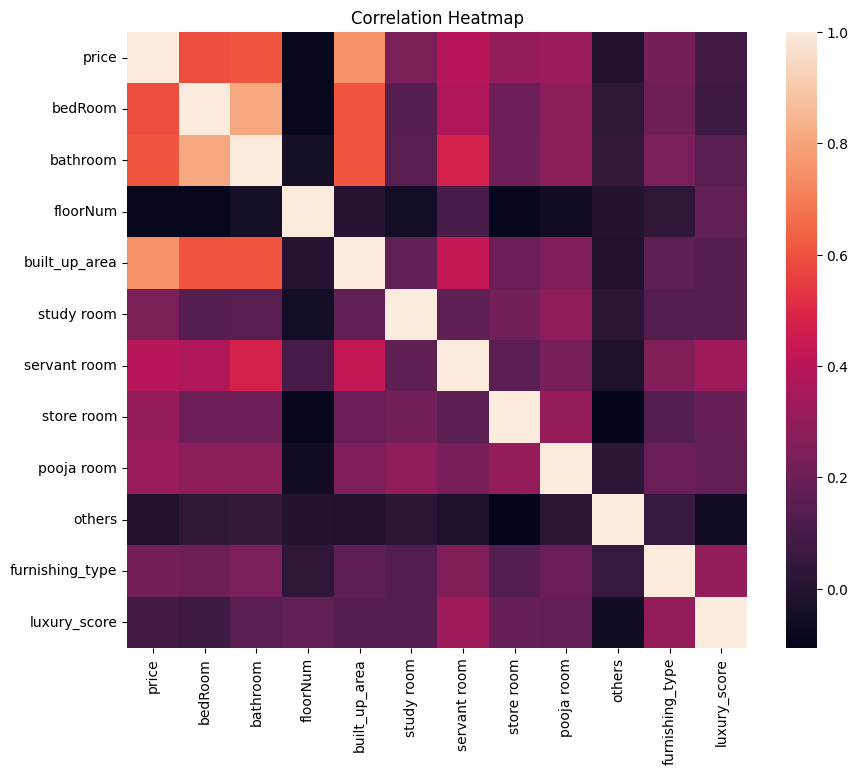

In [5]:
"""Plotting the correlation heatmap to visualize the relationships between features."""
plt.figure(figsize=(10, 8))
numeric_df = train_df.select_dtypes(include=['number'])
sns.heatmap(numeric_df.corr())
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
"""Correlation of features with the target variable 'price'."""
# print(train_df.corr()['price'].sort_values(ascending=False)) # Show some strong Multicollinearity between features.

ValueError: could not convert string to float: 'flat'

## Luxury Score

<Axes: ylabel='luxury_score'>

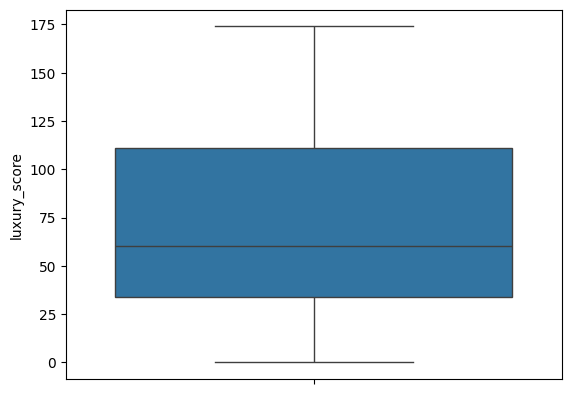

In [14]:
sns.boxplot(train_df['luxury_score'])

In [6]:
def categorize_luxury_score(score):
    if 0 <= score <= 50:
        return 'Low'
    elif 51 <= score <= 100:
        return 'Medium'
    elif 101 <= score:
        return 'High'
    else:
        return None

In [7]:
train_df['luxury_category'] = train_df['luxury_score'].apply(categorize_luxury_score)

In [20]:
train_df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,luxury_category
0,flat,sector 36,0.82,3.0,2.0,2,2.0,New Property,850.0,0.0,0.0,0.0,0.0,0.0,0.0,8.0,Low
1,flat,sector 89,0.95,2.0,2.0,2,4.0,New Property,1226.0,1.0,1.0,0.0,0.0,0.0,0.0,38.0,Low
2,flat,sohna road,0.32,2.0,2.0,1,17.0,New Property,1000.0,0.0,0.0,0.0,0.0,0.0,0.0,49.0,Low
3,flat,sector 92,1.60,3.0,4.0,3+,10.0,Relatively New,1615.0,0.0,1.0,0.0,0.0,1.0,1.0,174.0,High
4,flat,sector 102,0.48,2.0,2.0,1,5.0,Relatively New,582.0,0.0,0.0,1.0,0.0,0.0,0.0,159.0,High


## Floor Num

<Axes: ylabel='floorNum'>

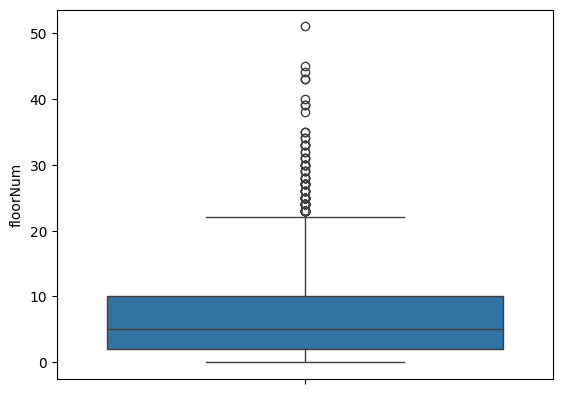

In [21]:
sns.boxplot(df['floorNum'])

In [8]:
def categorize_floor(floor):
    if 0 <= floor <= 2:
        return 'Lower'
    elif 3 <= floor <= 10:
        return 'Medium'
    elif 11 <= floor <= 51:
        return 'Higher'
    else:
        return None

In [9]:
train_df['floor_category'] = train_df['floorNum'].apply(categorize_floor)
train_df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,luxury_category,floor_category
0,flat,sector 36,0.82,3.0,2.0,2,2.0,New Property,850.0,0.0,0.0,0.0,0.0,0.0,0.0,8.0,Low,Lower
1,flat,sector 89,0.95,2.0,2.0,2,4.0,New Property,1226.0,1.0,1.0,0.0,0.0,0.0,0.0,38.0,Low,Medium
2,flat,sohna road,0.32,2.0,2.0,1,17.0,New Property,1000.0,0.0,0.0,0.0,0.0,0.0,0.0,49.0,Low,Higher
3,flat,sector 92,1.60,3.0,4.0,3+,10.0,Relatively New,1615.0,0.0,1.0,0.0,0.0,1.0,1.0,174.0,High,Medium
4,flat,sector 102,0.48,2.0,2.0,1,5.0,Relatively New,582.0,0.0,0.0,1.0,0.0,0.0,0.0,159.0,High,Medium


In [10]:
train_df.drop(columns=['luxury_score', 'floorNum'], inplace=True)

In [11]:
train_df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_category,floor_category
0,flat,sector 36,0.82,3.0,2.0,2,New Property,850.0,0.0,0.0,0.0,0.0,0.0,0.0,Low,Lower
1,flat,sector 89,0.95,2.0,2.0,2,New Property,1226.0,1.0,1.0,0.0,0.0,0.0,0.0,Low,Medium
2,flat,sohna road,0.32,2.0,2.0,1,New Property,1000.0,0.0,0.0,0.0,0.0,0.0,0.0,Low,Higher
3,flat,sector 92,1.60,3.0,4.0,3+,Relatively New,1615.0,0.0,1.0,0.0,0.0,1.0,1.0,High,Medium
4,flat,sector 102,0.48,2.0,2.0,1,Relatively New,582.0,0.0,0.0,1.0,0.0,0.0,0.0,High,Medium


In [15]:
# Exporting Data For Model Selection
special_export_df = train_df.drop(columns=['study room', 'pooja room', 'others'])
special_export_df.to_csv("my_gurgaon_properties_post_feature_selection_v2.csv", index=False)

## Encoding

In [30]:
from sklearn.preprocessing import OrdinalEncoder

# Create a copy of the Original Data for label encoding
data_label_encoding = train_df.copy()

categorical_cols = train_df.select_dtypes(include=['object']).columns

# Apply Ordinal Encoding to the categorical columns
for col in categorical_cols:
    oe = OrdinalEncoder()
    data_label_encoding[col] = oe.fit_transform(data_label_encoding[[col]])
    print(oe.categories_)

# Splitting the data into training & testing sets
X_label = data_label_encoding.drop('price', axis=1)
y_label = data_label_encoding['price']

[array(['flat', 'house'], dtype=object)]
[array(['dwarka expressway', 'gwal pahari', 'manesar', 'sector 1',
       'sector 10', 'sector 102', 'sector 103', 'sector 104',
       'sector 105', 'sector 106', 'sector 107', 'sector 108',
       'sector 109', 'sector 11', 'sector 110', 'sector 111',
       'sector 112', 'sector 113', 'sector 12', 'sector 13', 'sector 14',
       'sector 15', 'sector 17', 'sector 2', 'sector 21', 'sector 22',
       'sector 23', 'sector 24', 'sector 25', 'sector 26', 'sector 27',
       'sector 28', 'sector 3', 'sector 30', 'sector 31', 'sector 33',
       'sector 36', 'sector 37', 'sector 37d', 'sector 38', 'sector 39',
       'sector 4', 'sector 40', 'sector 41', 'sector 43', 'sector 45',
       'sector 46', 'sector 47', 'sector 48', 'sector 49', 'sector 5',
       'sector 50', 'sector 51', 'sector 52', 'sector 53', 'sector 54',
       'sector 55', 'sector 56', 'sector 57', 'sector 58', 'sector 59',
       'sector 6', 'sector 60', 'sector 61', 'sector 62', 

In [34]:
X_label.head()

,property_type,sector,bedRoom,bathroom,balcony,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_category,floor_category
0,0.0,36.0,3.0,2.0,2.0,1.0,850.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
1,0.0,95.0,2.0,2.0,2.0,1.0,1226.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,2.0
2,0.0,103.0,2.0,2.0,1.0,1.0,1000.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0.0,99.0,3.0,4.0,4.0,3.0,1615.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,2.0
4,0.0,5.0,2.0,2.0,1.0,3.0,582.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2.0


In [35]:
y_label.head()

0    0.82
1    0.95
2    0.32
3    1.60
4    0.48
Name: price, dtype: float64

## Feature Selection Techniques

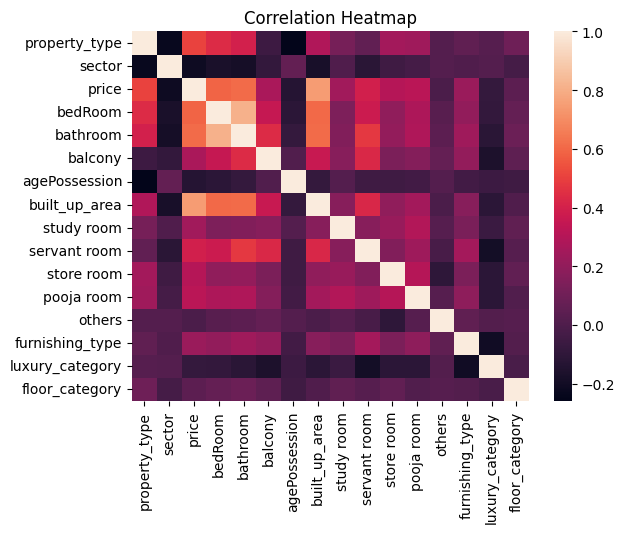

In [37]:
# 1. Correlation Analysis
sns.heatmap(data_label_encoding.corr())
plt.title('Correlation Heatmap')
plt.show()

In [38]:
fi_df1 = data_label_encoding.corr()['price'].iloc[1:].to_frame().reset_index().rename(columns={'index': 'Feature', 'price': 'Correlation'})
fi_df1

,Feature,Correlation
0,sector,-0.212084
1,price,1.000000
2,bedRoom,0.591289
3,bathroom,0.609777
4,balcony,0.269637
5,agePossession,-0.134171
6,built_up_area,0.748574
7,study room,0.242955
8,servant room,0.391930
9,store room,0.305677


In [54]:
# 2. Random Forest Feature Importance
from sklearn.ensemble import RandomForestRegressor

# Train a Random Forest Regressor to compute feature importance
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_label, y_label)

# Extract feature importance
fi_df2 = pd.DataFrame({'Feature': X_label.columns, 'ImportanceRF': rf.feature_importances_})
fi_df2 = fi_df2.sort_values('ImportanceRF', ascending=False)
fi_df2

,Feature,ImportanceRF
6,built_up_area,0.649950
1,sector,0.102995
0,property_type,0.100073
3,bathroom,0.026672
2,bedRoom,0.023658
8,servant room,0.019508
5,agePossession,0.013936
4,balcony,0.012703
12,furnishing_type,0.010298
7,study room,0.008878


In [55]:
# 3. Gradient Boosting Feature Importance
from sklearn.ensemble import GradientBoostingRegressor

# Train a Gradient Boosting Regressor to compute feature importance
gb = GradientBoostingRegressor()
gb.fit(X_label, y_label)

# Extract feature importance
fi_df3 = pd.DataFrame({'Feature': X_label.columns, 'ImportanceGB': gb.feature_importances_})
fi_df3 = fi_df3.sort_values('ImportanceGB', ascending=False)
fi_df3

,Feature,ImportanceGB
6,built_up_area,0.676378
1,sector,0.104112
0,property_type,0.098021
2,bedRoom,0.038813
3,bathroom,0.035844
8,servant room,0.023143
9,store room,0.010340
5,agePossession,0.004043
7,study room,0.003435
12,furnishing_type,0.002932


In [56]:
# 4. Permutation Importance
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_label, y_label, test_size=0.2, random_state=42)

# Train a Random Forest Regressor for permutation importance
rf_perm = RandomForestRegressor(n_estimators=100, random_state=42)
rf_perm.fit(X_train, y_train)

# Compute permutation importance
perm_importance = permutation_importance(rf_perm, X_test, y_test, n_repeats=10, random_state=42)

# Extract feature importance
fi_df4 = pd.DataFrame({'Feature': X_label.columns, 'ImportancePI': perm_importance.importances_mean})
fi_df4 = fi_df4.sort_values('ImportancePI', ascending=False)
fi_df4

,Feature,ImportancePI
6,built_up_area,0.750419
0,property_type,0.209932
1,sector,0.173595
8,servant room,0.025052
2,bedRoom,0.024731
3,bathroom,0.020583
5,agePossession,0.006185
9,store room,0.001702
14,floor_category,0.001433
11,others,0.000584


In [57]:
# 5. Lasso
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_label)

# Train a Lasso regression model
# We use a small alpha (the regularization strength) to allow for some features to be selected
lasso = Lasso(alpha=0.1, random_state=42)
lasso.fit(X_scaled, y_label)

# Extract feature importance (coefficients)
fi_df5 = pd.DataFrame({'Feature': X_label.columns, 'ImportanceLS': lasso.coef_})
fi_df5 = fi_df5.sort_values('ImportanceLS', ascending=False)
fi_df5

,Feature,ImportanceLS
6,built_up_area,1.489908
0,property_type,0.680381
3,bathroom,0.278293
9,store room,0.162200
7,study room,0.117472
8,servant room,0.109652
12,furnishing_type,0.096992
10,pooja room,0.046096
4,balcony,0.000000
1,sector,-0.000000


In [58]:
# 6. RFE -> Recursive Feature Elimination
from sklearn.feature_selection import RFE

# Initialize a Random Forest Regressor for RFE
rf_rfe = RandomForestRegressor()

# Apply RFE on label encoded data and standardized training data
selector_label = RFE(estimator=rf_rfe, n_features_to_select=X_label.shape[1], step=1)
selector_label = selector_label.fit(X_label, y_label)

# Get the selected features based on RFE
selected_features = X_label.columns[selector_label.support_]

# Extract the coefficients of the selected features from the underlying linear regession model
selected_coefficients = selector_label.estimator_.feature_importances_

# Organize the selected features and their importance into a DataFrame
fi_df6 = pd.DataFrame({'Feature': selected_features, 'ImportanceRFE': selected_coefficients})
fi_df6 = fi_df6.sort_values('ImportanceRFE', ascending=False)
fi_df6

,Feature,ImportanceRFE
6,built_up_area,0.647261
1,sector,0.103968
0,property_type,0.102445
3,bathroom,0.025574
2,bedRoom,0.025521
8,servant room,0.020704
5,agePossession,0.013998
4,balcony,0.012788
12,furnishing_type,0.010283
13,luxury_category,0.007971


In [59]:
# 7. Linear Regression Weights
from sklearn.linear_model import LinearRegression 

linear_reg = LinearRegression()
linear_reg.fit(X_label, y_label)

# Extract feature importance (coefficients)
fi_df7 = pd.DataFrame({'Feature': X_label.columns, 'ImportanceLR': linear_reg.coef_})
fi_df7 = fi_df7.sort_values('ImportanceLR', ascending=False)
fi_df7

,Feature,ImportanceLR
0,property_type,1.732069
9,store room,0.736154
7,study room,0.463589
8,servant room,0.355293
12,furnishing_type,0.300329
10,pooja room,0.208467
3,bathroom,0.194709
13,luxury_category,0.078623
2,bedRoom,0.013831
6,built_up_area,0.001246


In [48]:
# 8. SHAP
import shap

# Compute SHAP values for the Random Forest model
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_label, y_label)

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_label)

# Summing the absolute SHAP values across all samples to get an overall measure of feature importance
shap_sum = np.abs(shap_values).mean(axis=0)

shap_values

c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


array([[-1.81153682e-01,  1.47873854e-01, -3.41276669e-02, ...,
        -1.24827619e-02, -2.45035853e-03, -9.27895778e-03],
       [-1.98921360e-01, -3.96966070e-01, -4.96093254e-02, ...,
        -1.14352614e-02, -2.16375546e-03, -3.33642046e-03],
       [-1.75597862e-01, -4.17986923e-01, -4.76560534e-02, ...,
        -1.37541175e-02, -1.00986510e-02, -1.27681418e-02],
       ...,
       [-1.83103707e-01,  6.95555913e-02, -6.53827455e-03, ...,
         4.90302880e-03,  1.99233645e-02, -4.04247148e-03],
       [ 1.50808308e+00,  9.30738247e-01,  3.63087704e-01, ...,
         6.66032042e-02,  1.18729948e-01,  3.96978126e-02],
       [-3.21466361e-01,  8.77344074e-04, -2.63607421e-02, ...,
         1.91503573e-03,  2.36297635e-02,  3.29540269e-02]],
      shape=(3554, 15))

In [60]:
fi_df8 = pd.DataFrame({
    'Feature': X_label.columns,
    'SHAP_score': np.abs(shap_values).mean(axis=0)
}).sort_values(by='SHAP_score', ascending=False)

fi_df8

,Feature,SHAP_score
6,built_up_area,1.254662
0,property_type,0.472127
1,sector,0.381717
3,bathroom,0.112583
8,servant room,0.096238
2,bedRoom,0.050835
4,balcony,0.041367
12,furnishing_type,0.028529
5,agePossession,0.027217
14,floor_category,0.024733


In [61]:
final_fi_df = fi_df1.merge(fi_df2,on='Feature').merge(fi_df3,on='Feature').merge(fi_df4,on='Feature').merge(fi_df5,on='Feature').merge(fi_df6,on='Feature').merge(fi_df7,on='Feature').merge(fi_df8,on='Feature').set_index('Feature')
final_fi_df

,Correlation,ImportanceRF,ImportanceGB,ImportancePI,ImportanceLS,ImportanceRFE,ImportanceLR,SHAP_score
Feature,,,,,,,,
sector,-0.212084,0.102995,0.104112,0.173595,-0.000000,0.103968,-0.002399,0.381717
bedRoom,0.591289,0.023658,0.038813,0.024731,0.000000,0.025521,0.013831,0.050835
bathroom,0.609777,0.026672,0.035844,0.020583,0.278293,0.025574,0.194709,0.112583
balcony,0.269637,0.012703,0.001334,-0.000105,0.000000,0.012788,-0.053187,0.041367
agePossession,-0.134171,0.013936,0.004043,0.006185,-0.000000,0.013998,-0.002281,0.027217
built_up_area,0.748574,0.649950,0.676378,0.750419,1.489908,0.647261,0.001246,1.254662
study room,0.242955,0.008878,0.003435,-0.015416,0.117472,0.007124,0.463589,0.019112
servant room,0.391930,0.019508,0.023143,0.025052,0.109652,0.020704,0.355293,0.096238
store room,0.305677,0.008310,0.010340,0.001702,0.162200,0.006308,0.736154,0.017174


In [62]:
# normalize the score
final_fi_df = final_fi_df.divide(final_fi_df.sum(axis=0), axis=1)

In [64]:
final_fi_df[['ImportanceRF','ImportanceGB','ImportancePI','ImportanceRFE','SHAP_score']].mean(axis=1).sort_values(ascending=False)

Feature
built_up_area      0.711631
sector             0.141051
bathroom           0.034547
bedRoom            0.029456
servant room       0.028399
agePossession      0.010979
balcony            0.009908
store room         0.007537
furnishing_type    0.006667
floor_category     0.005704
luxury_category    0.005149
pooja room         0.003688
study room         0.003013
others             0.002271
dtype: float64

In [65]:
# to drop pooja room, study room, others
X_label

,property_type,sector,bedRoom,bathroom,balcony,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_category,floor_category
0,0.0,36.0,3.0,2.0,2.0,1.0,850.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
1,0.0,95.0,2.0,2.0,2.0,1.0,1226.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,2.0
2,0.0,103.0,2.0,2.0,1.0,1.0,1000.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0.0,99.0,3.0,4.0,4.0,3.0,1615.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,2.0
4,0.0,5.0,2.0,2.0,1.0,3.0,582.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3549,0.0,90.0,2.0,2.0,1.0,3.0,532.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0
3550,1.0,12.0,5.0,5.0,4.0,3.0,6228.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0
3551,0.0,23.0,1.0,1.0,1.0,0.0,665.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,2.0
3552,1.0,44.0,5.0,6.0,3.0,0.0,5490.0,1.0,1.0,1.0,1.0,0.0,0.0,2.0,2.0


In [66]:
# with all cols
from sklearn.model_selection import cross_val_score

rf = RandomForestRegressor(n_estimators=100, random_state=42)

scores =  cross_val_score(rf, X_label, y_label, cv=5, scoring='r2')

In [67]:
scores.mean()

np.float64(0.8206439828998026)

In [68]:
# with dropping of pooja room, study room, others

rf = RandomForestRegressor(n_estimators=100, random_state=42)

scores =  cross_val_score(rf, X_label.drop(columns=['pooja room', 'study room', 'others']), y_label, cv=5, scoring='r2')

In [69]:
scores.mean()

np.float64(0.8195451872629789)

In [70]:
export_df = X_label.drop(columns=['pooja room', 'study room', 'others'])
export_df['price'] = y_label

In [71]:
export_df.to_csv("my_gurgaon_properties_post_feature_selection.csv", index=False)